In [1]:
# ============================================================
# 01 - EXPLORATION DES DONNÉES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Affichage propre des graphiques
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Lister tous les fichiers disponibles dans data/raw/
fichiers = os.listdir('../data/raw/')
print(f"Nombre de fichiers : {len(fichiers)}")
print("\nFichiers disponibles :")
for f in fichiers:
    print(f" - {f}")

Nombre de fichiers : 13

Fichiers disponibles :
 - AEP_hourly.csv
 - COMED_hourly.csv
 - DAYTON_hourly.csv
 - DEOK_hourly.csv
 - DOM_hourly.csv
 - DUQ_hourly.csv
 - EKPC_hourly.csv
 - FE_hourly.csv
 - NI_hourly.csv
 - PJME_hourly.csv
 - PJMW_hourly.csv
 - pjm_hourly_est.csv
 - PJM_Load_hourly.csv


In [2]:
# ============================================================
# Chargement du fichier principal
# ============================================================

df = pd.read_csv('../data/raw/pjm_hourly_est.csv')

print("=== DIMENSIONS ===")
print(f"Lignes : {df.shape[0]:,}")
print(f"Colonnes : {df.shape[1]}")

print("\n=== PREMIÈRES LIGNES ===")
print(df.head(10))

print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)

print("\n=== STATISTIQUES DE BASE ===")
print(df.describe())

=== DIMENSIONS ===
Lignes : 178,262
Colonnes : 13

=== PREMIÈRES LIGNES ===
              Datetime  AEP  COMED  DAYTON  DEOK  DOM  DUQ  EKPC  FE  NI  \
0  1998-12-31 01:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
1  1998-12-31 02:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
2  1998-12-31 03:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
3  1998-12-31 04:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
4  1998-12-31 05:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
5  1998-12-31 06:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
6  1998-12-31 07:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
7  1998-12-31 08:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
8  1998-12-31 09:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
9  1998-12-31 10:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   

   PJME  PJMW  PJM_Load  
0   NaN   NaN   29309.0  
1   NaN   NaN   28236.0  
2   NaN  

## Choix de la variable cible

Ce dataset contient 12 colonnes de consommation, chacune représentant une région différente du réseau PJM.

Nous devons choisir **une seule série temporelle** comme variable cible pour nos modèles de prévision.

### Critère principal : volume de données

Nos données sont **horaires**. Pour qu'un modèle apprenne correctement les patterns énergétiques (cycles journaliers, hebdomadaires, saisonniers), il doit voir chaque 
cycle se répéter un grand nombre de fois.

| Colonne | Valeurs disponibles | Période couverte |
|---------|-------------------|-----------------|
| PJME | ~145,000 | ~16 ans |
| AEP | ~121,000 | ~14 ans |
| PJM_Load | ~32,000 | ~4 ans |

Avec seulement ~4 ans de données (`PJM_Load`), le modèle ne verrait chaque saison que 4 fois, ce qui n'est pas assez suffisant pour être robuste face à des années atypiques (canicule exceptionnelle, hiver doux, etc.).

### Choix retenu : PJME

`PJME` (PJM Est) est la colonne la plus complète avec ~16 ans de données horaires. Elle couvre la zone Est du réseau PJM, la plus large et la plus représentative. C'est le meilleur compromis entre **volume**, **qualité** et **représentativité**.

## Analyse de la série PJME

On a choisi notre variable cible, l'objectif maintenat est:
1. Isoler la colonne PJME
2. Convertir la date en format datetime
3. Analyser les valeurs manquantes
4. Visualiser la série complète

In [3]:
# ============================================================
# Isolation de PJME et conversion de la date
# ============================================================

# Uniquement les colonnes utiles
df_pjme = df[['Datetime', 'PJME']].copy()

# Conversion de la date (actuellement un string) en vrai datetime
df_pjme['Datetime'] = pd.to_datetime(df_pjme['Datetime'])

# On définit la date comme index (standard pour les séries temporelles)
df_pjme = df_pjme.set_index('Datetime')

# On trie par date 
df_pjme = df_pjme.sort_index()

print("=== APERÇU ===")
print(df_pjme.head(10))

print("\n=== PÉRIODE COUVERTE ===")
print(f"Début : {df_pjme.index.min()}")
print(f"Fin   : {df_pjme.index.max()}")
print(f"Durée : {(df_pjme.index.max() - df_pjme.index.min()).days // 365} ans")

print("\n=== VALEURS MANQUANTES ===")
total = len(df_pjme)
manquantes = df_pjme['PJME'].isna().sum()
print(f"Total lignes      : {total:,}")
print(f"Valeurs manquantes: {manquantes:,}")
print(f"Pourcentage       : {manquantes/total*100:.2f}%")

=== APERÇU ===
                     PJME
Datetime                 
1998-04-01 01:00:00   NaN
1998-04-01 02:00:00   NaN
1998-04-01 03:00:00   NaN
1998-04-01 04:00:00   NaN
1998-04-01 05:00:00   NaN
1998-04-01 06:00:00   NaN
1998-04-01 07:00:00   NaN
1998-04-01 08:00:00   NaN
1998-04-01 09:00:00   NaN
1998-04-01 10:00:00   NaN

=== PÉRIODE COUVERTE ===
Début : 1998-04-01 01:00:00
Fin   : 2018-08-03 00:00:00
Durée : 20 ans

=== VALEURS MANQUANTES ===
Total lignes      : 178,262
Valeurs manquantes: 32,896
Pourcentage       : 18.45%


## Localisation des valeurs manquantes

La base contient 18.45% de valeurs manquantes, ce qui est beaucoup, mais la question clé est :
**où sont-elles ?** En fonction de leurs positions on aura une idée de la cause et on pourra les imputer si nécessaire.

Première valeur non-nulle : 2002-01-01 01:00:00

NaN avant la première valeur : 32,896
NaN après la première valeur : 0


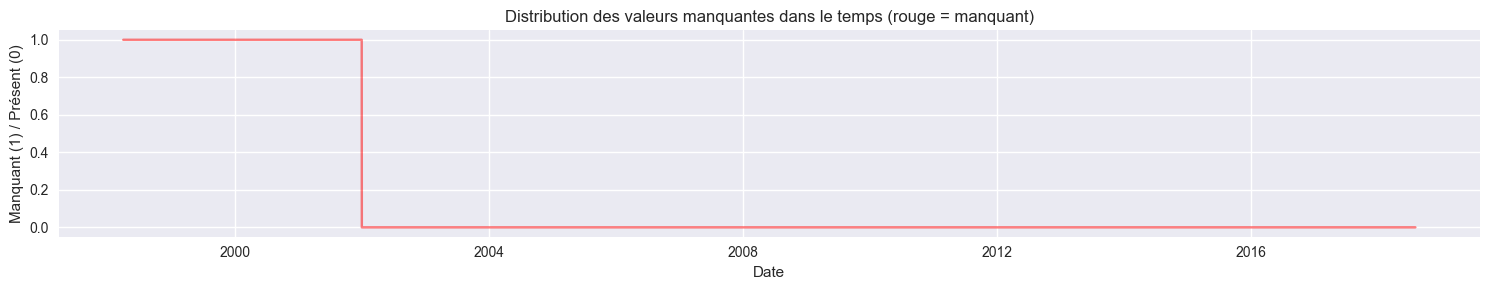

In [4]:
# ============================================================
# Localisation des valeurs manquantes
# ============================================================

# Trouver la première valeur non-nulle
premiere_valeur = df_pjme['PJME'].first_valid_index()
print(f"Première valeur non-nulle : {premiere_valeur}")

# Compter les NaN avant et après cette date
nan_avant = df_pjme.loc[:premiere_valeur, 'PJME'].isna().sum()
nan_apres = df_pjme.loc[premiere_valeur:, 'PJME'].isna().sum()

print(f"\nNaN avant la première valeur : {nan_avant:,}")
print(f"NaN après la première valeur : {nan_apres:,}")

# Visualiser la distribution des NaN dans le temps
plt.figure(figsize=(15, 3))
plt.plot(df_pjme.index, df_pjme['PJME'].isna().astype(int), 
         color='red', alpha=0.5)
plt.title('Distribution des valeurs manquantes dans le temps (rouge = manquant)')
plt.xlabel('Date')
plt.ylabel('Manquant (1) / Présent (0)')
plt.tight_layout()
plt.show()

## Traitement des valeurs manquantes

On vois clairement que les 32,896 NaN sont **entièrement concentrés avant janvier 2002**, il est donc probable que  l'entreprise ne reportait pas encore ses données. Il n'y a aucune valeur manquante après cette date.

On va juste supprimé les lignes antérieures à 2002. 
Aucune imputation n'est nécessaire. Il nous reste ~16 ans de données horaires complètes (2002 → 2018).

In [5]:
# ============================================================
# Suppression des lignes avant 2002 (toutes NaN)
# ============================================================

df_pjme = df_pjme.loc['2002-01-01':]

print(f"Lignes après nettoyage : {len(df_pjme):,}")
print(f"Début : {df_pjme.index.min()}")
print(f"Fin   : {df_pjme.index.max()}")
print(f"Valeurs manquantes restantes : {df_pjme['PJME'].isna().sum()}")

Lignes après nettoyage : 145,367
Début : 2002-01-01 00:00:00
Fin   : 2018-08-03 00:00:00
Valeurs manquantes restantes : 1


In [6]:
# ============================================================
# Localiser l'unique valeur manquante restante
# ============================================================

ligne_manquante = df_pjme[df_pjme['PJME'].isna()]
print("Ligne manquante :")
print(ligne_manquante)

# Regarder les valeurs autour pour comprendre le contexte
idx = ligne_manquante.index[0]
print("\nContexte (2h avant et 2h après) :")
print(df_pjme.loc[idx - pd.Timedelta(hours=2) : idx + pd.Timedelta(hours=2)])

Ligne manquante :
            PJME
Datetime        
2002-01-01   NaN

Contexte (2h avant et 2h après) :
                        PJME
Datetime                    
2002-01-01 00:00:00      NaN
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0


## Traitement de la valeur manquante résiduelle

Il reste une unique valeur manquante : **minuit le 1er janvier 2002**, qui est la toute première ligne de la série. Il n'existe aucune valeur antérieure pour contextualiser une imputation.

On supprime cette ligne. Perdre 1 heure sur 145,367 lignes (0.0007%) n'a aucun impact sur nos modèles, et évite d'introduire une valeur artificielle.

In [7]:
# ============================================================
# Suppression de l'unique valeur manquante résiduelle
# ============================================================

df_pjme = df_pjme.dropna()

print(f"Lignes finales         : {len(df_pjme):,}")
print(f"Début                  : {df_pjme.index.min()}")
print(f"Fin                    : {df_pjme.index.max()}")
print(f"Valeurs manquantes     : {df_pjme['PJME'].isna().sum()}")
print(f"\n Série complète et prête pour l'analyse")

Lignes finales         : 145,366
Début                  : 2002-01-01 01:00:00
Fin                    : 2018-08-03 00:00:00
Valeurs manquantes     : 0

 Série complète et prête pour l'analyse
